# Notebook para testing de selecciones #

*En este notebook se harán pruebas prediciendo con KNN sobre los csv filtrados generados por el selector de atributos.*

(Imports para predicción)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## A_data

Comenzaremos con uno de los csv generados, por ejemplo A_data_output de `input_csv_files/individual_stocks_5yr`. Para empezar la selección de atributos se realizó sobre el csv transformado con parámetros fv=5, fh=20, ph=20.
Este csv contiene columnas: date, open, high, low, close, volume, name.

Las selecciones con distintos métodos primero han sido con únicamente cinco variables seleccionadas.

Para cambiar esto hay que ejecutar:
``python time_series_framework.py individual_stocks_5yr\A_data.csv A_data_output --fv valor_fv --fh valor_fh --ph valor_ph --feature_selection --fs_method metodo_seleccion --fs_n_features valor_n_features --time_col nombre_columna_tiempo
``

Hay una carpeta `/feature_selection_metodo`por método y en cada una estará el csv `filtered_data_metodo.csv` con el último filtrado ejecutado.

In [3]:
# Configuración
A_CSV_FOLDER = "results/A_data_output/feature_selection_"
FILTERED_FILE = "filtered_data_"
TARGET_COLUMN = "volume"
TIME_COLUMN = "date"
TEST_SIZE = 0.2  

### A_data con PCA

In [4]:
CSV_FILE = A_CSV_FOLDER + "pca/" + FILTERED_FILE + "pca.csv"
df = pd.read_csv(CSV_FILE)
if TIME_COLUMN and TIME_COLUMN in df.columns:
    df = df.sort_values(TIME_COLUMN).reset_index(drop=True)

X_pca = df.drop(columns=[TARGET_COLUMN, TIME_COLUMN]) # Knn no acepta variables no numericas
y_pca = df[TARGET_COLUMN]
display(df.head(), X_pca.shape, y_pca.shape)

,date,volume_t-19,volume_t-2,volume_t-18,volume_t-15,volume_t-3,volume
0,2013-03-08,2915405,2414186,2373731,14657315,2996908,3256301
1,2013-03-11,2373731,3256301,2052338,4116141,2414186,5472837
2,2013-03-12,2052338,5472837,3826245,3873183,3256301,3767613
3,2013-03-13,3826245,3767613,14657315,3415149,5472837,2241086
4,2013-03-14,14657315,2241086,4116141,3354862,3767613,2840603


(1220, 5)

(1220,)

Split sencillo en train y test:

In [5]:
split_idx = int(len(X_pca) * (1 - TEST_SIZE))

X_train_pca, X_test_pca = X_pca.iloc[:split_idx], X_pca.iloc[split_idx:]
y_train_pca, y_test_pca = y_pca.iloc[:split_idx], y_pca.iloc[split_idx:]

print(X_train_pca.shape, X_test_pca.shape)

(976, 5) (244, 5)


Escalar y entrenar el modelo:

In [6]:
knn_pipeline_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))    
])

#Entrenamiento
knn_pipeline_pca.fit(X_train_pca, y_train_pca)

#Predicción
y_pred_pca = knn_pipeline_pca.predict(X_test_pca)

#Evaluación
rmse_pca = np.sqrt(mean_squared_error(y_test_pca, y_pred_pca))
mae_pca = mean_absolute_error(y_test_pca, y_pred_pca)
r2_pca = r2_score(y_test_pca, y_pred_pca)

print(f"RMSE: {rmse_pca:.4f} | MAE: {mae_pca:.4f} | R²: {r2_pca:.4f}")


RMSE: 889143.4359 | MAE: 618108.2377 | R²: -0.0260


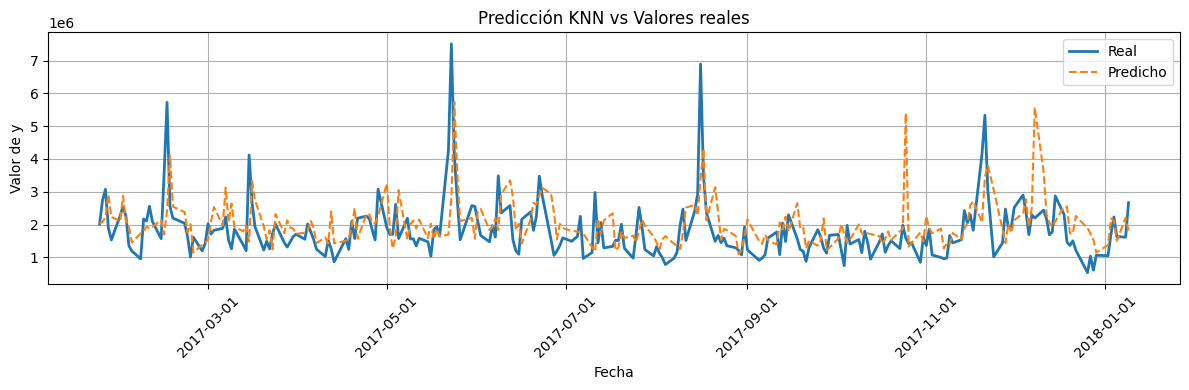

In [7]:
# Suponiendo que tienes:
# dates -> pd.Series o np.array de tipo datetime
# y_test -> valores reales
# y_pred -> valores predichos
# Supongamos que df ya está ordenado por tiempo
dates = pd.to_datetime(df[TIME_COLUMN].iloc[-len(y_test_pca):])  # fechas correspondientes al test
plt.figure(figsize=(12,4))
plt.plot(dates, y_test_pca.values, label="Real", linewidth=2)
plt.plot(dates, y_pred_pca, label="Predicho", linestyle="--")

plt.title("Predicción KNN vs Valores reales")
plt.xlabel("Fecha")
plt.ylabel("Valor de y")
plt.legend()
plt.grid(True)

# --- Ajuste automático de ticks ---
ax = plt.gca()  # obtener eje actual
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # ticks automáticos según rango
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # formato de fecha
plt.xticks(rotation=45)  # rotar etiquetas para legibilidad
plt.tight_layout()
plt.show()


### A_data con Lasso

In [8]:
# Lectura
CSV_FILE = A_CSV_FOLDER + "lasso/" + FILTERED_FILE + "lasso.csv"
df = pd.read_csv(CSV_FILE)
if TIME_COLUMN and TIME_COLUMN in df.columns:
    df = df.sort_values(TIME_COLUMN).reset_index(drop=True)

X_lasso = df.drop(columns=[TARGET_COLUMN, TIME_COLUMN]) # Knn no acepta variables no numericas
y_lasso = df[TARGET_COLUMN]
display(df.head(), X_lasso.shape, y_lasso.shape)

,date,volume_t-1,low_t-1,high_t-1,close_t-1,open_t-20,volume
0,2013-03-08,3256301,43.02,43.52,43.03,45.07,3256301
1,2013-03-11,5472837,41.73,43.01,42.81,45.17,5472837
2,2013-03-12,3767613,42.59,43.00,42.62,44.81,3767613
3,2013-03-13,2241086,42.40,43.05,43.00,44.81,2241086
4,2013-03-14,2840603,43.00,43.38,43.32,44.72,2840603


(1220, 5)

(1220,)

In [9]:
# Split Train & Test
split_idx = int(len(X_lasso) * (1 - TEST_SIZE))

X_train_lasso, X_test_lasso = X_lasso.iloc[:split_idx], X_lasso.iloc[split_idx:]
y_train_lasso, y_test_lasso = y_lasso.iloc[:split_idx], y_lasso.iloc[split_idx:]

print(X_train_lasso.shape, X_test_lasso.shape)

(976, 5) (244, 5)


In [10]:
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsRegressor(n_neighbors=5))    
])

#Entrenamiento
knn_pipeline.fit(X_train_lasso, y_train_lasso)

#Predicción
y_pred_lasso = knn_pipeline.predict(X_test_lasso)

#Evaluación
rmse = np.sqrt(mean_squared_error(y_test_lasso, y_pred_lasso))
mae = mean_absolute_error(y_test_lasso, y_pred_lasso)
r2 = r2_score(y_test_lasso, y_pred_lasso)

print(f"RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")


RMSE: 520079.6859 | MAE: 355475.5107 | R²: 0.6490


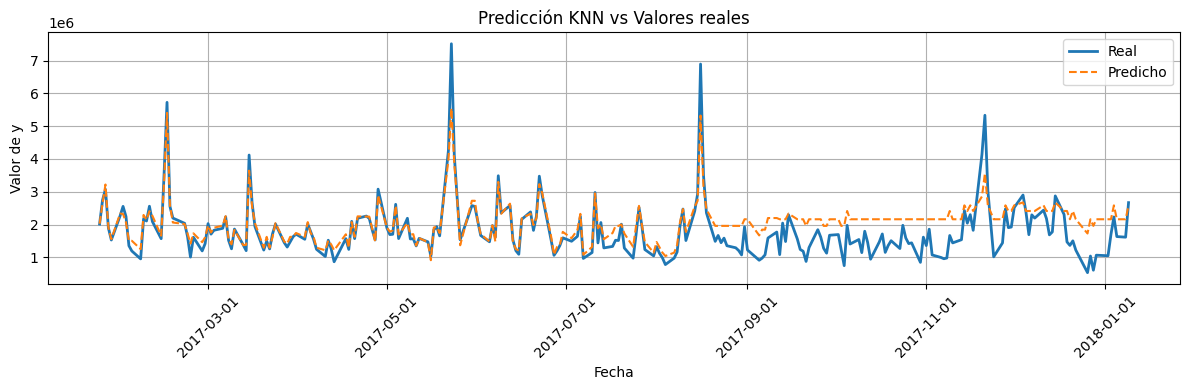

In [11]:
# Suponiendo que tienes:
# dates -> pd.Series o np.array de tipo datetime
# y_test -> valores reales
# y_pred -> valores predichos
# Supongamos que df ya está ordenado por tiempo
dates = pd.to_datetime(df[TIME_COLUMN].iloc[-len(y_test_lasso):])  # fechas correspondientes al test
plt.figure(figsize=(12,4))
plt.plot(dates, y_test_lasso.values, label="Real", linewidth=2)
plt.plot(dates, y_pred_lasso, label="Predicho", linestyle="--")

plt.title("Predicción KNN vs Valores reales")
plt.xlabel("Fecha")
plt.ylabel("Valor de y")
plt.legend()
plt.grid(True)

# --- Ajuste automático de ticks ---
ax = plt.gca()  # obtener eje actual
ax.xaxis.set_major_locator(mdates.AutoDateLocator())  # ticks automáticos según rango
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))  # formato de fecha
plt.xticks(rotation=45)  # rotar etiquetas para legibilidad
plt.tight_layout()
plt.show()


Ahora que ya se ha hecho con dos métodos individualmente, vamos a realizar una función para trabajar con el resto más fácilmente:

In [12]:
def evaluate_knn(csv_folder, filtered_file, method, target_col, time_col, n_neighbors=5, test_size=0.2):
    # 1. Leer datos 
    # (csv_folder="results/<nombrecsv>_output/feature_selection_)
    # (filtered_file="filtered_data_")
    file_to_read = csv_folder + method + "/" + filtered_file + method + ".csv"
    df = pd.read_csv(file_to_read)
    df[time_col] = pd.to_datetime(df[time_col])
    df = df.sort_values(time_col).reset_index(drop=True)
    
    # 2. Separar X e y
    X = df.drop(columns=[target_col, time_col])
    y = df[target_col]
    
    # 3. Dividir train/test temporalmente
    split_idx = int(len(df) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    dates_test = df[time_col].iloc[split_idx:]
    
    # 4. Modelo base
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsRegressor(n_neighbors=n_neighbors))
    ])
    
    # 5. Entrenar y predecir
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    # 6. Calcular métricas
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return {
        "csv": file_to_read,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "y_test": y_test,
        "y_pred": y_pred,
        "dates": dates_test
    }


In [13]:
methods = [
    'pearson', 'ccf', 'mutual_info', 'random_forest',
    'lasso', 'elastic_net', 'rfe', 'granger', 'pca',
    'spectral', 'sequential' #, 'genetic'
]

results = []

for m in methods:
    r = evaluate_knn(method = m, csv_folder=A_CSV_FOLDER, filtered_file=FILTERED_FILE, target_col=TARGET_COLUMN, time_col=TIME_COLUMN)
    r["method"] = m
    results.append(r)



In [14]:
# Comparación numérica
metrics_df = pd.DataFrame(results)[["method", "rmse", "mae", "r2"]]
display(metrics_df.sort_values("rmse"))

,method,rmse,mae,r2
3,random_forest,3.049684e+05,212421.359016,0.879295
6,rfe,3.074917e+05,213679.731148,0.877290
2,mutual_info,3.097359e+05,193376.684426,0.875492
0,pearson,3.130706e+05,215713.589344,0.872796
1,ccf,3.130706e+05,215713.589344,0.872796
5,elastic_net,3.130706e+05,215713.589344,0.872796
10,sequential,3.949999e+05,261123.354918,0.797508
4,lasso,5.200797e+05,355475.510656,0.648962
8,pca,8.891434e+05,618108.237705,-0.026026
7,granger,1.111877e+06,883081.750820,-0.604458


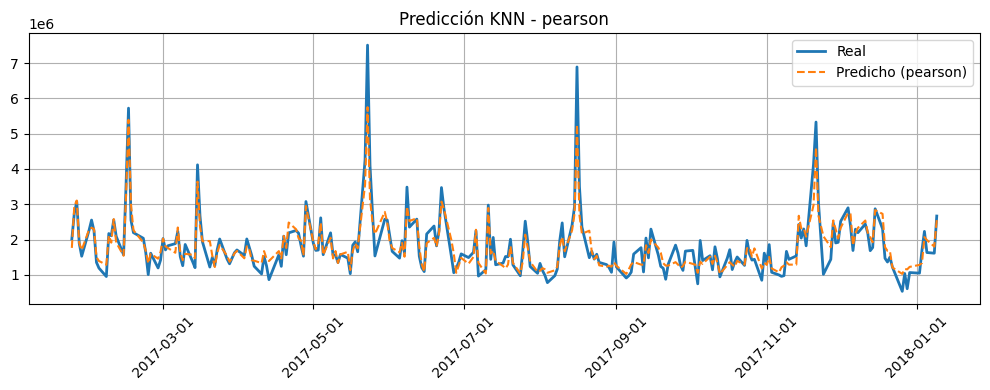

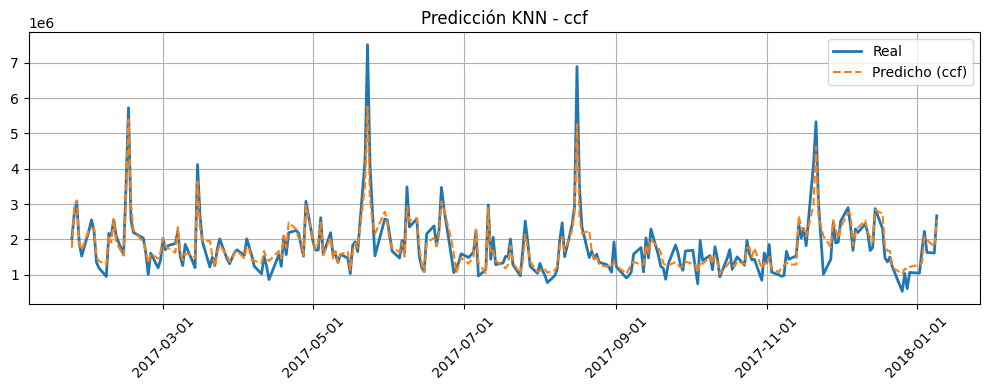

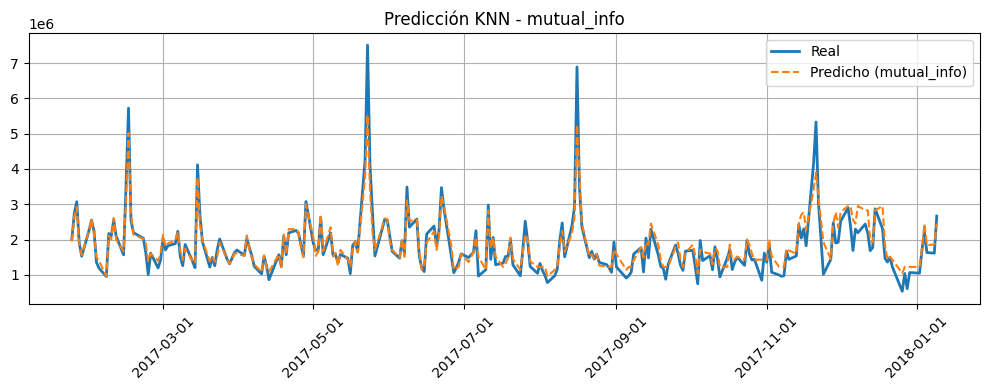

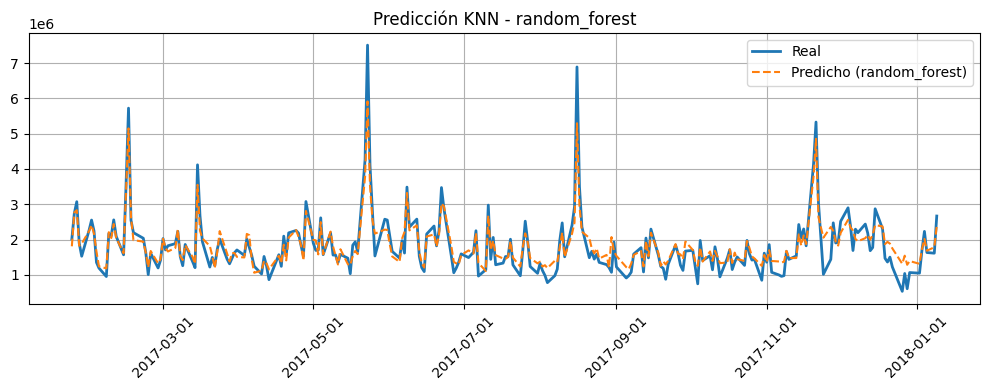

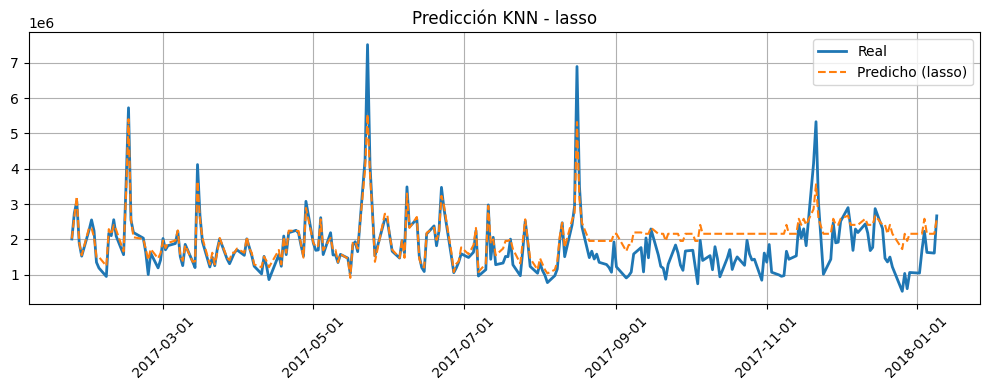

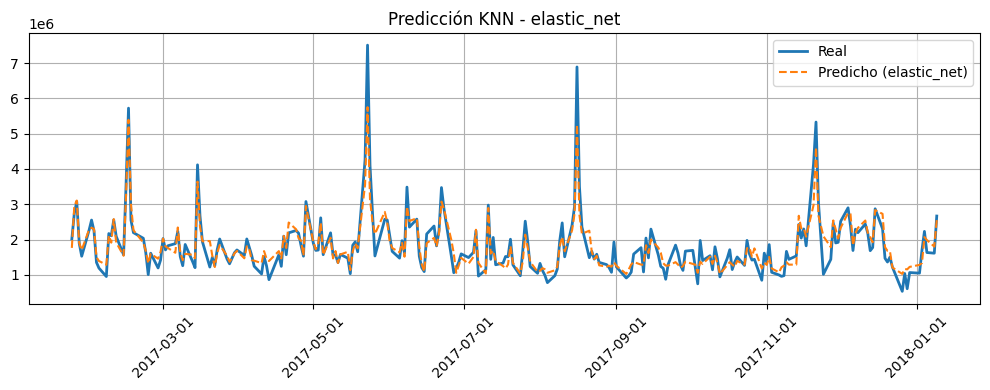

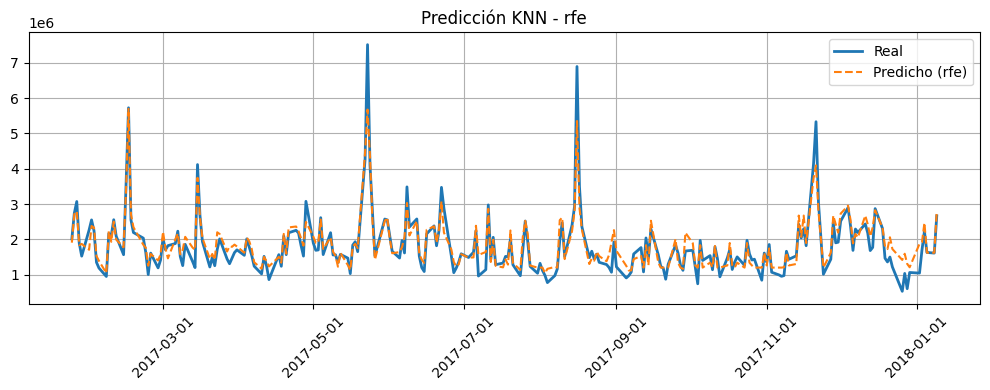

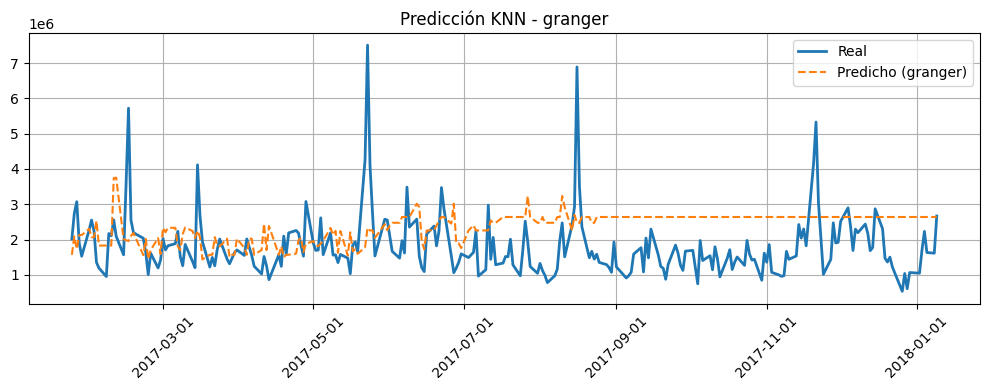

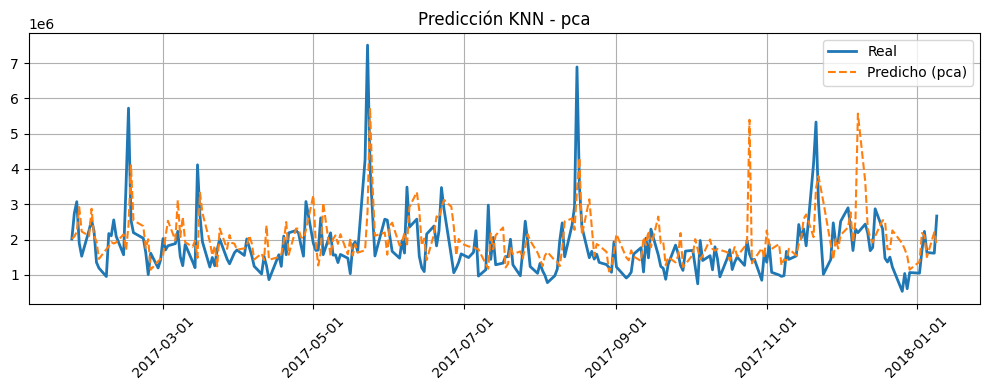

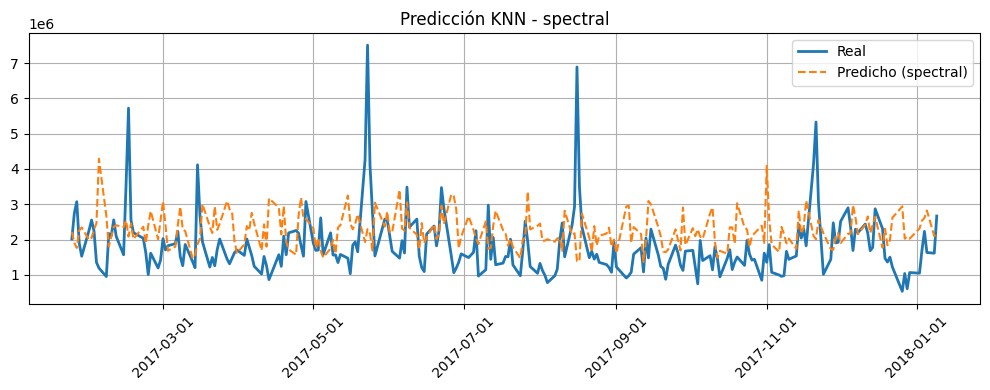

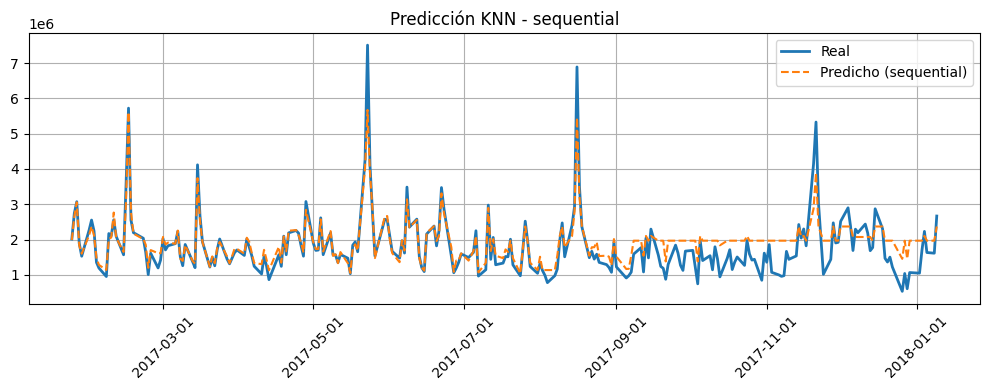

In [15]:
for r in results:
    plt.figure(figsize=(10,4))
    plt.plot(r["dates"], r["y_test"].values, label="Real", linewidth=2)
    plt.plot(r["dates"], r["y_pred"], label=f"Predicho ({r['method']})", linestyle="--")
    plt.title(f"Predicción KNN - {r['method']}")
    plt.legend()
    plt.grid(True)
    plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
